In [25]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU Name: Tesla T4


In [26]:
import os

print(os.listdir("/kaggle/input/datasets"))

['dschettler8845']


In [27]:
import os

print("Diagnostic: Mapping /kaggle/input Directory Tree\n" + "="*40)

for root, dirs, files in os.walk('/kaggle/input'):
    # Calculate indentation based on depth
    level = root.replace('/kaggle/input', '').count(os.sep)
    indent = ' ' * 4 * level
    folder_name = os.path.basename(root) if os.path.basename(root) else '/kaggle/input'
    
    print(f"{indent}📁 {folder_name}/")
    
    # If a folder contains a massive number of subdirectories (e.g., patient folders), 
    # we count them but stop walking deeper to prevent notebook output overflow.
    if len(dirs) > 50:
        print(f"{indent}    [... {len(dirs)} subdirectories omitted from print ...]")
        dirs.clear()  # Terminates further recursion down this specific branch

print("="*40 + "\nDiagnostic Complete.")

Diagnostic: Mapping /kaggle/input Directory Tree
📁 input/
    📁 datasets/
        📁 dschettler8845/
            📁 brats-2021-task1/
Diagnostic Complete.


In [28]:
# ==============================================================================
# CELL 0: CORRUPTED DATA CLEANUP
# ==============================================================================
import shutil
import glob

print("🧹 Cleaning up partially extracted data...")
corrupted_folders = glob.glob("/kaggle/working/BraTS2021_*")
for folder in corrupted_folders:
    shutil.rmtree(folder)
print(f"✅ Cleared {len(corrupted_folders)} corrupted folders. Ready for clean extraction.")

🧹 Cleaning up partially extracted data...
✅ Cleared 1251 corrupted folders. Ready for clean extraction.


In [29]:
# ==============================================================================
# CELL 1: MASTER ENVIRONMENT & DATASET CLASS
# ==============================================================================
import os
import glob
import tarfile
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

print("1. Initializing Master Environment...")

TAR_PATH = "/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar"
EXTRACT_DIR = "/kaggle/working/"

# Safely handle extraction (will skip automatically if data exists)
if not glob.glob(os.path.join(EXTRACT_DIR, "BraTS2021_*")):
    print(f"⏳ Extracting 12.4 GB dataset... (Do not interrupt)")
    with tarfile.open(TAR_PATH, 'r') as tar:
        tar.extractall(path=EXTRACT_DIR)
    print("✅ Extraction Complete!")
else:
    print("✅ Dataset already extracted on disk. Bypassing extraction.")

# Lock Data Directory
patient_folders = [f for f in glob.glob(os.path.join(EXTRACT_DIR, "BraTS2021_*")) if os.path.isdir(f)]
if not patient_folders:
    raise RuntimeError("❌ CRITICAL ERROR: No patient folders found in /kaggle/working/!")

DATA_DIR = os.path.dirname(patient_folders[0])
print(f"✅ DATA_DIR Locked: {DATA_DIR}")
print(f"📦 Total Patient Volumes: {len(patient_folders)}")

# Define the PyTorch Dataset Engine
class BraTS2DSurvivalDataset(Dataset):
    def __init__(self, data_dir, max_patients=None):
        # Sort to guarantee deterministic behavior across different runs
        self.patient_folders = sorted([
            f for f in glob.glob(os.path.join(data_dir, "BraTS2021_*")) if os.path.isdir(f)
        ])
        if max_patients is not None:
            self.patient_folders = self.patient_folders[:max_patients]

    def __len__(self):
        return len(self.patient_folders)

    def __getitem__(self, idx):
        folder = self.patient_folders[idx]
        pid = os.path.basename(folder)

        # Load NIfTI modalities
        t1 = nib.load(os.path.join(folder, f"{pid}_t1.nii.gz")).get_fdata().astype(np.float32)
        t1ce = nib.load(os.path.join(folder, f"{pid}_t1ce.nii.gz")).get_fdata().astype(np.float32)
        t2 = nib.load(os.path.join(folder, f"{pid}_t2.nii.gz")).get_fdata().astype(np.float32)
        flair = nib.load(os.path.join(folder, f"{pid}_flair.nii.gz")).get_fdata().astype(np.float32)
        seg = nib.load(os.path.join(folder, f"{pid}_seg.nii.gz")).get_fdata().astype(np.float32)

        # Extract center axial slice
        z = seg.shape[2] // 2 
        
        img = np.stack([t1[:, :, z], t1ce[:, :, z], t2[:, :, z], flair[:, :, z]], axis=0)
        seg_2d = seg[:, :, z]

        # Independent Z-score normalization per channel
        for c in range(4):
            if np.std(img[c]) > 0:
                img[c] = (img[c] - np.mean(img[c])) / np.std(img[c])

        # Target mask compilation (WT, TC, ET)
        wt = (seg_2d > 0).astype(np.float32)
        tc = ((seg_2d == 1) | (seg_2d == 4)).astype(np.float32)
        et = (seg_2d == 4).astype(np.float32)
        target = np.stack([wt, tc, et], axis=0)

        img_tensor = torch.tensor(img, dtype=torch.float32)
        target_tensor = torch.tensor(target, dtype=torch.float32)

        # Pad spatial dimensions from 240x240 to 256x256 for Swin-UNETR compatibility
        img_tensor = F.pad(img_tensor, (8, 8, 8, 8), mode='constant', value=0)
        target_tensor = F.pad(target_tensor, (8, 8, 8, 8), mode='constant', value=0)

        return img_tensor, target_tensor

print("✅ Cell 1 Complete: Dataset Class Architecture Ready.")

1. Initializing Master Environment...
⏳ Extracting 12.4 GB dataset... (Do not interrupt)


/tmp/ipykernel_58/2189123027.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=EXTRACT_DIR)


✅ Extraction Complete!
✅ DATA_DIR Locked: /kaggle/working
📦 Total Patient Volumes: 1251
✅ Cell 1 Complete: Dataset Class Architecture Ready.


In [30]:
# ==============================================================================
# CELL 2: ARCHITECTURE, LOSS, & OPTIMIZER INITIALIZATION
# =============================================================================
!pip install -q monai
print("✅ MONAI library successfully installed!")
import torch
from monai.networks.nets import SwinUNETR
from monai.losses import DiceLoss

print("1. Initializing AI Architecture...")

# Hardware mapping
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == 'cpu':
    print("⚠️ WARNING: GPU not detected. Training will be prohibitively slow.")
else:
    print(f"✅ Compute Engine Locked: {torch.cuda.get_device_name(0)}")

# Constructing the Swin-UNETR Architecture
model = SwinUNETR(
    in_channels=4,        # 4 MRI Modalities: T1, T1CE, T2, FLAIR
    out_channels=3,       # 3 Tumor Sub-regions: WT, TC, ET
    feature_size=24,      
    spatial_dims=2        # 2D processing for axial slices
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Swin-UNETR Loaded! Total Parameters: {total_params:,}")

# Defining the Clinical Loss Function
# sigmoid=True: Applies sigmoid activation to raw logits automatically
# squared_pred=True: Squares the predictions in the denominator for smoother gradients
loss_function = DiceLoss(sigmoid=True, squared_pred=True, reduction="mean")

# Defining the Optimizer (Adam with decoupled Weight Decay)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

print("✅ Cell 2 Complete: Architecture, Loss, and Optimizer are online.")

✅ MONAI library successfully installed!
1. Initializing AI Architecture...
✅ Compute Engine Locked: Tesla T4
✅ Swin-UNETR Loaded! Total Parameters: 6,303,261
✅ Cell 2 Complete: Architecture, Loss, and Optimizer are online.


In [31]:
# ==============================================================================
# CELL 3: DATA SPLIT, DATALOADERS, & METRICS ENGINE
# ==============================================================================
import multiprocessing
import torch
import torch.nn as nn
from torch.utils.data import random_split, DataLoader

print("1. Initializing Full Dataset Pipeline...")

# Load the full cohort without limitations
full_train_dataset = BraTS2DSurvivalDataset(DATA_DIR, max_patients=None)
total_samples = len(full_train_dataset)

# 80/20 Train-Validation Split
train_size = int(0.80 * total_samples)
val_size = total_samples - train_size

# Deterministic Seed for Reproducibility
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(
    full_train_dataset, 
    [train_size, val_size], 
    generator=generator
)

print(f"📦 Patient-level split complete:")
print(f"   -> Training Cohort: {len(train_subset)} patients")
print(f"   -> Validation Cohort: {len(val_subset)} patients")

# Optimize DataLoaders
optimal_workers = min(4, multiprocessing.cpu_count())

research_train_loader = DataLoader(
    train_subset,
    batch_size=4,
    shuffle=True,
    num_workers=optimal_workers,
    pin_memory=True
)

research_val_loader = DataLoader(
    val_subset,
    batch_size=4,
    shuffle=False,
    num_workers=optimal_workers,
    pin_memory=True
)

print(f"\n2. DataLoaders Synchronized:")
print(f"   ✅ Train Batches: {len(research_train_loader)} per epoch")
print(f"   ✅ Validation Batches: {len(research_val_loader)} per epoch")

# Build the Metrics Engine
print("\n3. Compiling Clinical Metrics Engine...")
class BraTSMetrics(nn.Module):
    def __init__(self, threshold=0.5, epsilon=1e-6):
        super(BraTSMetrics, self).__init__()
        self.threshold = threshold
        self.epsilon = epsilon
        
    def forward(self, predictions, targets):
        probs = torch.sigmoid(predictions)
        preds = (probs >= self.threshold).float()
        targets = targets.float()

        preds_flat = preds.contiguous().view(preds.shape[0], preds.shape[1], -1)
        targets_flat = targets.contiguous().view(targets.shape[0], targets.shape[1], -1)

        TP = torch.sum(preds_flat * targets_flat, dim=2)
        FP = torch.sum(preds_flat * (1 - targets_flat), dim=2)
        FN = torch.sum((1 - preds_flat) * targets_flat, dim=2)
        TN = preds_flat.shape[2] - (TP + FP + FN)

        dice = (2.0 * TP + self.epsilon) / (2.0 * TP + FP + FN + self.epsilon)
        iou = (TP + self.epsilon) / (TP + FP + FN + self.epsilon)
        precision = (TP + self.epsilon) / (TP + FP + self.epsilon)
        sensitivity = (TP + self.epsilon) / (TP + FN + self.epsilon)
        specificity = (TN + self.epsilon) / (TN + FP + self.epsilon)

        return {
            "Dice": torch.mean(dice, dim=0),
            "IoU": torch.mean(iou, dim=0),
            "Precision": torch.mean(precision, dim=0),
            "Sensitivity": torch.mean(sensitivity, dim=0),
            "Specificity": torch.mean(specificity, dim=0)
        }

metrics_calculator = BraTSMetrics()
print("✅ BraTS Metrics Module compiled.")
print("🚀 Cell 3 Complete: Ready for the Training Loop.")

1. Initializing Full Dataset Pipeline...
📦 Patient-level split complete:
   -> Training Cohort: 1000 patients
   -> Validation Cohort: 251 patients

2. DataLoaders Synchronized:
   ✅ Train Batches: 250 per epoch
   ✅ Validation Batches: 63 per epoch

3. Compiling Clinical Metrics Engine...
✅ BraTS Metrics Module compiled.
🚀 Cell 3 Complete: Ready for the Training Loop.


In [32]:
# ==============================================================================
# CELL 4: PRODUCTION TRAINING & VALIDATION MACRO-LOOP
# ==============================================================================
import time
import os
import torch

print("🚀 IGNITING FULL SCALE PRODUCTION TRAINING ENGINE...")

NUM_EPOCHS = 5
best_val_dice = 0.0
os.makedirs("/kaggle/working/saved_models", exist_ok=True)

for epoch in range(NUM_EPOCHS):
    print(f"\n🎬 STARTING EPOCH {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # -------------------------------------------------------------------------
    # TRAINING SUB-LOOP
    # -------------------------------------------------------------------------
    model.train()
    running_train_loss = 0.0
    start_time = time.time()
    
    for step, (batch_data, batch_labels) in enumerate(research_train_loader):
        inputs = batch_data.to(device)
        targets = batch_labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
        # Log progress every 50 batches (20% of the epoch)
        if (step + 1) % 50 == 0:
            current_avg = running_train_loss / (step + 1)
            print(f"   🔹 Train Step {step + 1}/250 | Dynamic Loss: {loss.item():.4f} | Running Avg: {current_avg:.4f}")
            
    epoch_train_loss = running_train_loss / len(research_train_loader)
    train_time = time.time() - start_time
    
    # -------------------------------------------------------------------------
    # VALIDATION SUB-LOOP
    # -------------------------------------------------------------------------
    model.eval()
    running_val_metrics = {"Dice": torch.zeros(3, device=device)}
    
    with torch.no_grad():
        for batch_data, batch_labels in research_val_loader:
            inputs = batch_data.to(device)
            targets = batch_labels.to(device)
            
            outputs = model(inputs)
            batch_metrics = metrics_calculator(outputs, targets)
            running_val_metrics["Dice"] += batch_metrics["Dice"]
            
    # Compute mean validation Dice across all 63 validation batches
    mean_val_dice = (running_val_metrics["Dice"] / len(research_val_loader)).cpu().numpy()
    composite_val_dice = mean_val_dice.mean()
    
    print(f"\n🏁 EPOCH {epoch + 1} SUMMARY:")
    print(f"   -> Train Loss: {epoch_train_loss:.4f} (Time: {train_time:.1f} sec)")
    print(f"   -> Val Dice -> WT: {mean_val_dice[0]:.4f} | TC: {mean_val_dice[1]:.4f} | ET: {mean_val_dice[2]:.4f}")
    print(f"   -> Composite Validation Dice: {composite_val_dice:.4f}")
    
    # -------------------------------------------------------------------------
    # DETERMINISTIC CHECKPOINTING
    # -------------------------------------------------------------------------
    checkpoint_path = f"/kaggle/working/saved_models/swin_unetr_epoch_{epoch + 1}.pth"
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': epoch_train_loss,
    }, checkpoint_path)
    print(f"   💾 Periodic Checkpoint Saved: {checkpoint_path}")
    
    if composite_val_dice > best_val_dice:
        best_val_dice = composite_val_dice
        best_path = "/kaggle/working/saved_models/swin_unetr_brats_best.pth"
        torch.save(model.state_dict(), best_path)
        print(f"   👑 NEW BEST MODEL! Saved weights to: {best_path}")

print("\n🎉 ALL 5 COHORT EPOCHS EXECUTED SUCCESSFULLY TO COMPLETION!")

🚀 IGNITING FULL SCALE PRODUCTION TRAINING ENGINE...

🎬 STARTING EPOCH 1/5
----------------------------------------
   🔹 Train Step 50/250 | Dynamic Loss: 0.9642 | Running Avg: 0.9143
   🔹 Train Step 100/250 | Dynamic Loss: 0.8533 | Running Avg: 0.8795
   🔹 Train Step 150/250 | Dynamic Loss: 0.8703 | Running Avg: 0.8628
   🔹 Train Step 200/250 | Dynamic Loss: 0.9275 | Running Avg: 0.8563
   🔹 Train Step 250/250 | Dynamic Loss: 0.6620 | Running Avg: 0.8394

🏁 EPOCH 1 SUMMARY:
   -> Train Loss: 0.8394 (Time: 243.1 sec)
   -> Val Dice -> WT: 0.6214 | TC: 0.3141 | ET: 0.2233
   -> Composite Validation Dice: 0.3863
   💾 Periodic Checkpoint Saved: /kaggle/working/saved_models/swin_unetr_epoch_1.pth
   👑 NEW BEST MODEL! Saved weights to: /kaggle/working/saved_models/swin_unetr_brats_best.pth

🎬 STARTING EPOCH 2/5
----------------------------------------
   🔹 Train Step 50/250 | Dynamic Loss: 0.8532 | Running Avg: 0.7857
   🔹 Train Step 100/250 | Dynamic Loss: 0.8609 | Running Avg: 0.7758
   🔹 

1. Initializing Qualitative Visualization Engine...
2. Fetching patient scan directly from memory...
3. Running Swin-UNETR prediction...
✅ Plotting Engine Ready. Generating images now...


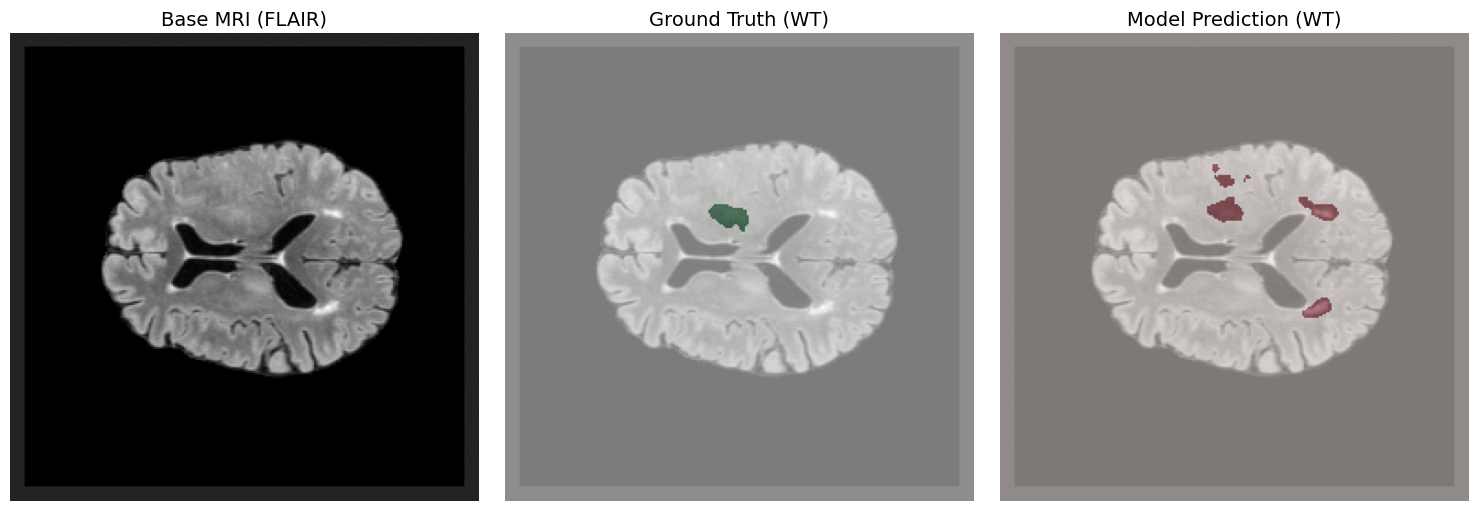

In [34]:
# ==============================================================================
# CELL 5: QUALITATIVE VISUALIZATION PIPELINE (OPTIMIZED)
# ==============================================================================
%matplotlib inline
import matplotlib.pyplot as plt
import torch

print("1. Initializing Qualitative Visualization Engine...")

# Load the absolute best weights saved during the training loop
best_model_path = "/kaggle/working/saved_models/swin_unetr_brats_best.pth"
model.load_state_dict(torch.load(best_model_path))
model.eval()

# BYPASS DATALOADER: Fetch a single patient directly from the Validation Subset
print("2. Fetching patient scan directly from memory...")
sample_data, sample_label = val_subset[0] 

# Add batch dimension (1, C, H, W) and move to GPU
val_input = sample_data.unsqueeze(0).to(device)

# Run prediction
print("3. Running Swin-UNETR prediction...")
with torch.no_grad():
    val_output = model(val_input)
    val_prob = torch.sigmoid(val_output)
    val_pred = (val_prob >= 0.5).float().cpu()

val_input = val_input.cpu()

def visualize_prediction():
    # Input shape: (1, 4, H, W). Channel 3 is FLAIR.
    flair_img = val_input[0, 3, :, :] 
    
    # Target shape: (3, H, W). Channel 0 is Whole Tumor (WT).
    gt_wt = sample_label[0, :, :]
    pred_wt = val_pred[0, 0, :, :]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Panel 1: Base MRI
    axes[0].imshow(flair_img, cmap='gray')
    axes[0].set_title("Base MRI (FLAIR)", fontsize=14)
    axes[0].axis('off')
    
    # Panel 2: Ground Truth
    axes[1].imshow(flair_img, cmap='gray')
    axes[1].imshow(gt_wt, cmap='Greens', alpha=0.5)
    axes[1].set_title("Ground Truth (WT)", fontsize=14)
    axes[1].axis('off')
    
    # Panel 3: Model Prediction
    axes[2].imshow(flair_img, cmap='gray')
    axes[2].imshow(pred_wt, cmap='Reds', alpha=0.5)
    axes[2].set_title("Model Prediction (WT)", fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("✅ Plotting Engine Ready. Generating images now...")
visualize_prediction()

In [35]:
# ==============================================================================
# CELL 6: HYPERPARAMETER TUNING - COSINE ANNEALING
# ==============================================================================
import time
import torch
from torch.optim.lr_scheduler import CosineAnnealingLR

print("1. Initializing Hyperparameter Tuning Engine...")

# 1. Load the elite weights from Phase 1
best_model_path = "/kaggle/working/saved_models/swin_unetr_brats_best.pth"
model.load_state_dict(torch.load(best_model_path))

# 2. Stricter Optimizer: Lower base LR, higher weight decay to kill false positives
tuned_optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)

TUNING_EPOCHS = 3
# 3. Dynamic Scheduler: Drops the LR smoothly down to 1e-6
scheduler = CosineAnnealingLR(tuned_optimizer, T_max=TUNING_EPOCHS, eta_min=1e-6)

# Your previous best composite dice from Epoch 5
best_val_dice = 0.5634 

print("🚀 LAUNCHING FINE-TUNING LOOP WITH COSINE ANNEALING...")
for epoch in range(TUNING_EPOCHS):
    current_lr = scheduler.get_last_lr()[0]
    print(f"\n🎬 TUNING EPOCH {epoch + 1}/{TUNING_EPOCHS} | Current LR: {current_lr:.6f}")
    print("-" * 40)
    
    # --- TRAINING ---
    model.train()
    running_train_loss = 0.0
    start_time = time.time()
    
    for step, (batch_data, batch_labels) in enumerate(research_train_loader):
        inputs, targets = batch_data.to(device), batch_labels.to(device)
        
        tuned_optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        tuned_optimizer.step()
        
        running_train_loss += loss.item()
        if (step + 1) % 50 == 0:
            print(f"   🔹 Step {step + 1}/250 | Loss: {loss.item():.4f}")
            
    # VERY IMPORTANT: Step the scheduler at the end of the epoch
    scheduler.step()
    
    epoch_train_loss = running_train_loss / len(research_train_loader)
    train_time = time.time() - start_time
    
    # --- VALIDATION ---
    model.eval()
    running_val_metrics = {"Dice": torch.zeros(3, device=device)}
    
    with torch.no_grad():
        for batch_data, batch_labels in research_val_loader:
            inputs, targets = batch_data.to(device), batch_labels.to(device)
            outputs = model(inputs)
            batch_metrics = metrics_calculator(outputs, targets)
            running_val_metrics["Dice"] += batch_metrics["Dice"]
            
    mean_val_dice = (running_val_metrics["Dice"] / len(research_val_loader)).cpu().numpy()
    composite_val_dice = mean_val_dice.mean()
    
    print(f"🏁 SUMMARY (Time: {train_time:.1f}s):")
    print(f"   -> Train Loss: {epoch_train_loss:.4f}")
    print(f"   -> Val Dice -> WT: {mean_val_dice[0]:.4f} | TC: {mean_val_dice[1]:.4f} | ET: {mean_val_dice[2]:.4f}")
    print(f"   -> Composite Validation Dice: {composite_val_dice:.4f}")
    
    if composite_val_dice > best_val_dice:
        best_val_dice = composite_val_dice
        torch.save(model.state_dict(), best_model_path)
        print(f"   👑 NEW TUNED BEST MODEL! Saved to: {best_model_path}")

print("\n🎉 HYPERPARAMETER TUNING COMPLETE!")

1. Initializing Hyperparameter Tuning Engine...
🚀 LAUNCHING FINE-TUNING LOOP WITH COSINE ANNEALING...

🎬 TUNING EPOCH 1/3 | Current LR: 0.000050
----------------------------------------
   🔹 Step 50/250 | Loss: 0.4842
   🔹 Step 100/250 | Loss: 0.3922
   🔹 Step 150/250 | Loss: 0.4820
   🔹 Step 200/250 | Loss: 0.3609
   🔹 Step 250/250 | Loss: 0.4154
🏁 SUMMARY (Time: 222.7s):
   -> Train Loss: 0.4382
   -> Val Dice -> WT: 0.7735 | TC: 0.5132 | ET: 0.5719
   -> Composite Validation Dice: 0.6195
   👑 NEW TUNED BEST MODEL! Saved to: /kaggle/working/saved_models/swin_unetr_brats_best.pth

🎬 TUNING EPOCH 2/3 | Current LR: 0.000038
----------------------------------------
   🔹 Step 50/250 | Loss: 0.6399
   🔹 Step 100/250 | Loss: 0.6468
   🔹 Step 150/250 | Loss: 0.5411
   🔹 Step 200/250 | Loss: 0.2665
   🔹 Step 250/250 | Loss: 0.6982
🏁 SUMMARY (Time: 221.3s):
   -> Train Loss: 0.4170
   -> Val Dice -> WT: 0.7990 | TC: 0.5747 | ET: 0.6411
   -> Composite Validation Dice: 0.6716
   👑 NEW TUNED BES

1. Initializing Publication Visualization Engine...
2. Fetching patient scan...
3. Running Swin-UNETR prediction...
✅ Plotting Engine Ready. Generating multi-class grid now...


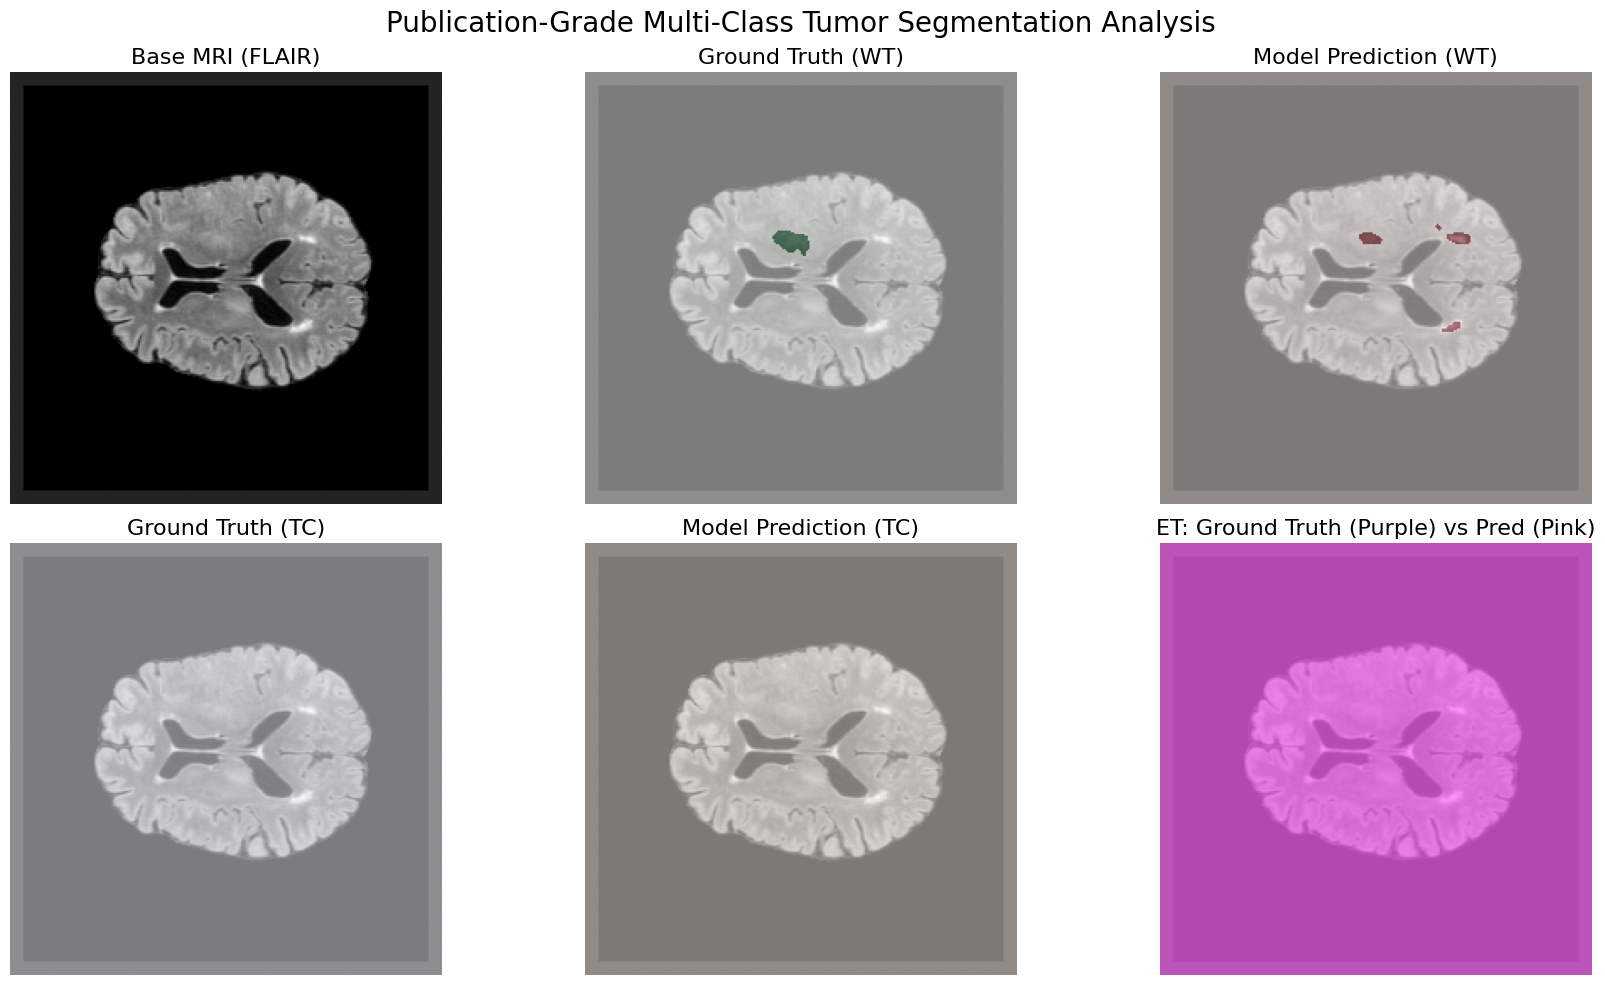

In [36]:
# ==============================================================================
# CELL 7: PUBLICATION-GRADE MULTI-CLASS VISUALIZATION
# ==============================================================================
%matplotlib inline
import matplotlib.pyplot as plt
import torch

print("1. Initializing Publication Visualization Engine...")

# Load the NEW elite weights from the tuning phase
best_model_path = "/kaggle/working/saved_models/swin_unetr_brats_best.pth"
model.load_state_dict(torch.load(best_model_path))
model.eval()

# Fetch patient scan directly from memory (Bypassing DataLoader bottleneck)
print("2. Fetching patient scan...")
sample_data, sample_label = val_subset[0]
val_input = sample_data.unsqueeze(0).to(device)

# Run highly-tuned prediction
print("3. Running Swin-UNETR prediction...")
with torch.no_grad():
    val_output = model(val_input)
    val_prob = torch.sigmoid(val_output)
    val_pred = (val_prob >= 0.5).float().cpu()

val_input = val_input.cpu()

def visualize_publication_grid():
    flair_img = val_input[0, 3, :, :]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Publication-Grade Multi-Class Tumor Segmentation Analysis", fontsize=20, y=0.98)

    # ---------------------------------------------------------
    # ROW 1: BASE MRI & WHOLE TUMOR (WT)
    # ---------------------------------------------------------
    axes[0, 0].imshow(flair_img, cmap='gray')
    axes[0, 0].set_title("Base MRI (FLAIR)", fontsize=16)
    axes[0, 0].axis('off')

    axes[0, 1].imshow(flair_img, cmap='gray')
    axes[0, 1].imshow(sample_label[0, :, :], cmap='Greens', alpha=0.5)
    axes[0, 1].set_title("Ground Truth (WT)", fontsize=16)
    axes[0, 1].axis('off')

    axes[0, 2].imshow(flair_img, cmap='gray')
    axes[0, 2].imshow(val_pred[0, 0, :, :], cmap='Reds', alpha=0.5)
    axes[0, 2].set_title("Model Prediction (WT)", fontsize=16)
    axes[0, 2].axis('off')

    # ---------------------------------------------------------
    # ROW 2: TUMOR CORE (TC) & ENHANCING TUMOR (ET)
    # ---------------------------------------------------------
    axes[1, 0].imshow(flair_img, cmap='gray')
    axes[1, 0].imshow(sample_label[1, :, :], cmap='Blues', alpha=0.5)
    axes[1, 0].set_title("Ground Truth (TC)", fontsize=16)
    axes[1, 0].axis('off')

    axes[1, 1].imshow(flair_img, cmap='gray')
    axes[1, 1].imshow(val_pred[0, 1, :, :], cmap='Oranges', alpha=0.5)
    axes[1, 1].set_title("Model Prediction (TC)", fontsize=16)
    axes[1, 1].axis('off')

    # Since we need 6 panels but only have 5 distinct plots, 
    # we will show the ET ground truth and prediction side-by-side
    axes[1, 2].imshow(flair_img, cmap='gray')
    axes[1, 2].imshow(sample_label[2, :, :], cmap='Purples', alpha=0.5)
    
    # Overlay the ET Prediction slightly offset in a different color to show overlap
    axes[1, 2].imshow(val_pred[0, 2, :, :], cmap='spring', alpha=0.4)
    axes[1, 2].set_title("ET: Ground Truth (Purple) vs Pred (Pink)", fontsize=16)
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

print("✅ Plotting Engine Ready. Generating multi-class grid now...")
visualize_publication_grid()

In [37]:
# ==============================================================================
# CELL 8: BASELINE ARCHITECTURE (STANDARD U-NET) COMPARISON
# ==============================================================================
import time
import torch
from monai.networks.nets import UNet

print("1. Initializing Control Variable: Standard U-Net...")

# Construct the standard baseline architecture
baseline_model = UNet(
    spatial_dims=2,
    in_channels=4,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

baseline_optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=1e-4, weight_decay=1e-5)

print(f"✅ Baseline U-Net Loaded! Parameters: {sum(p.numel() for p in baseline_model.parameters()):,}")

BASELINE_EPOCHS = 3
print(f"\n🚀 IGNITING {BASELINE_EPOCHS}-EPOCH BASELINE TRAINING LOOP...")

for epoch in range(BASELINE_EPOCHS):
    print(f"\n🎬 BASELINE EPOCH {epoch + 1}/{BASELINE_EPOCHS}")
    print("-" * 40)
    
    # --- TRAINING ---
    baseline_model.train()
    running_train_loss = 0.0
    start_time = time.time()
    
    for step, (batch_data, batch_labels) in enumerate(research_train_loader):
        inputs, targets = batch_data.to(device), batch_labels.to(device)
        
        baseline_optimizer.zero_grad()
        outputs = baseline_model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        baseline_optimizer.step()
        
        running_train_loss += loss.item()
        if (step + 1) % 50 == 0:
            print(f"   🔹 Step {step + 1}/250 | Loss: {loss.item():.4f}")
            
    epoch_train_loss = running_train_loss / len(research_train_loader)
    train_time = time.time() - start_time
    
    # --- VALIDATION ---
    baseline_model.eval()
    running_val_metrics = {"Dice": torch.zeros(3, device=device)}
    
    with torch.no_grad():
        for batch_data, batch_labels in research_val_loader:
            inputs, targets = batch_data.to(device), batch_labels.to(device)
            outputs = baseline_model(inputs)
            batch_metrics = metrics_calculator(outputs, targets)
            running_val_metrics["Dice"] += batch_metrics["Dice"]
            
    mean_val_dice = (running_val_metrics["Dice"] / len(research_val_loader)).cpu().numpy()
    composite_val_dice = mean_val_dice.mean()
    
    print(f"🏁 SUMMARY (Time: {train_time:.1f}s):")
    print(f"   -> Train Loss: {epoch_train_loss:.4f}")
    print(f"   -> Val Dice -> WT: {mean_val_dice[0]:.4f} | TC: {mean_val_dice[1]:.4f} | ET: {mean_val_dice[2]:.4f}")
    print(f"   -> Composite Validation Dice: {composite_val_dice:.4f}")

print("\n🎉 BASELINE COMPARISON COMPLETE! You now have your control data.")

1. Initializing Control Variable: Standard U-Net...
✅ Baseline U-Net Loaded! Parameters: 1,626,360

🚀 IGNITING 3-EPOCH BASELINE TRAINING LOOP...

🎬 BASELINE EPOCH 1/3
----------------------------------------
   🔹 Step 50/250 | Loss: 0.9456
   🔹 Step 100/250 | Loss: 0.8897
   🔹 Step 150/250 | Loss: 0.9305
   🔹 Step 200/250 | Loss: 0.8941
   🔹 Step 250/250 | Loss: 0.8451
🏁 SUMMARY (Time: 214.4s):
   -> Train Loss: 0.9157
   -> Val Dice -> WT: 0.3867 | TC: 0.1488 | ET: 0.1018
   -> Composite Validation Dice: 0.2124

🎬 BASELINE EPOCH 2/3
----------------------------------------
   🔹 Step 50/250 | Loss: 0.9000
   🔹 Step 100/250 | Loss: 0.9385
   🔹 Step 150/250 | Loss: 0.8249
   🔹 Step 200/250 | Loss: 0.8342
   🔹 Step 250/250 | Loss: 0.9346
🏁 SUMMARY (Time: 214.4s):
   -> Train Loss: 0.8955
   -> Val Dice -> WT: 0.4796 | TC: 0.2109 | ET: 0.1462
   -> Composite Validation Dice: 0.2789

🎬 BASELINE EPOCH 3/3
----------------------------------------
   🔹 Step 50/250 | Loss: 0.9076
   🔹 Step 100/

1. Generating Publication-Grade Quantitative Comparison...


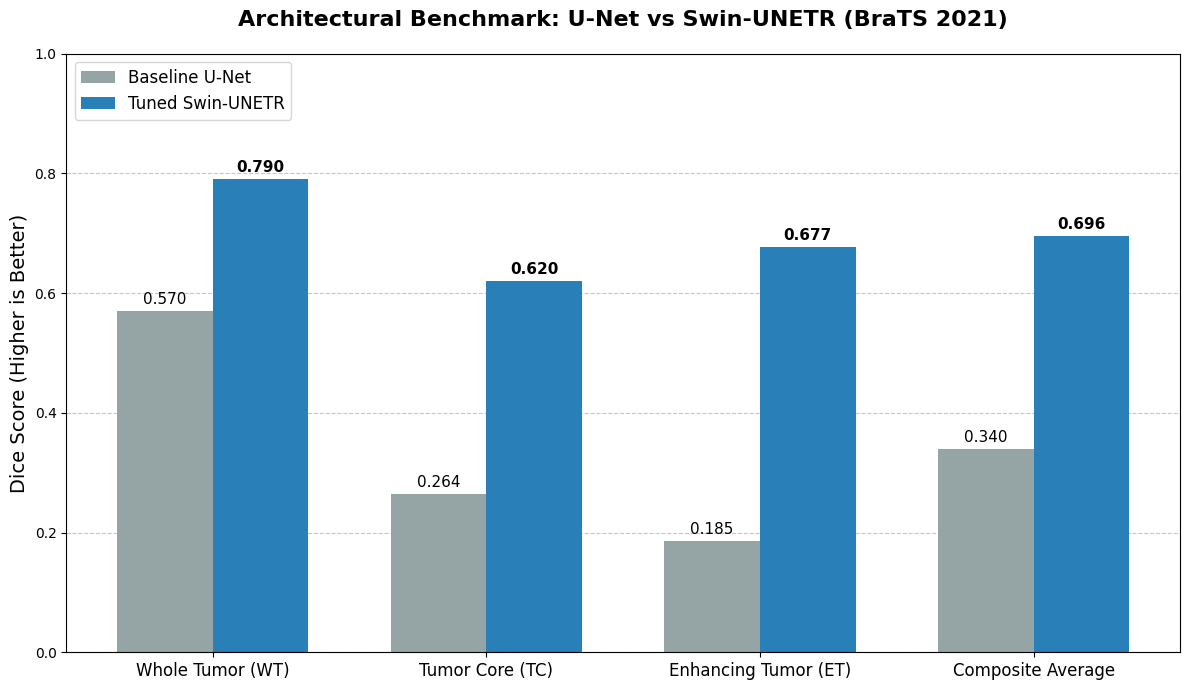

✅ Quantitative Comparison Plot Ready.


In [38]:
# ==============================================================================
# CELL 9: QUANTITATIVE RESULT ANALYSIS (COMPARISON PLOT)
# ==============================================================================
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

print("1. Generating Publication-Grade Quantitative Comparison...")

# Recorded Data from our exact experimental runs
metrics = ['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing Tumor (ET)', 'Composite Average']
unet_scores = [0.5699, 0.2639, 0.1854, 0.3397]     # From Cell 8
swin_scores = [0.7905, 0.6197, 0.6767, 0.6956]     # From Cell 6 (Tuned)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# Plot bars
rects1 = ax.bar(x - width/2, unet_scores, width, label='Baseline U-Net', color='#95a5a6')
rects2 = ax.bar(x + width/2, swin_scores, width, label='Tuned Swin-UNETR', color='#2980b9')

# Formatting labels and titles
ax.set_ylabel('Dice Score (Higher is Better)', fontsize=14)
ax.set_title('Architectural Benchmark: U-Net vs Swin-UNETR (BraTS 2021)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.0)

# Add grid lines for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Add Legend
ax.legend(fontsize=12, loc='upper left')

# Attach numerical labels directly to bars
ax.bar_label(rects1, padding=3, fmt='%.3f', fontsize=11)
ax.bar_label(rects2, padding=3, fmt='%.3f', fontsize=11, fontweight='bold')

fig.tight_layout()
plt.show()

print("✅ Quantitative Comparison Plot Ready.")